Saving ex7data2.mat to ex7data2.mat
Uploaded file: ex7data2.mat
Shape of X: (300, 2)
[[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]


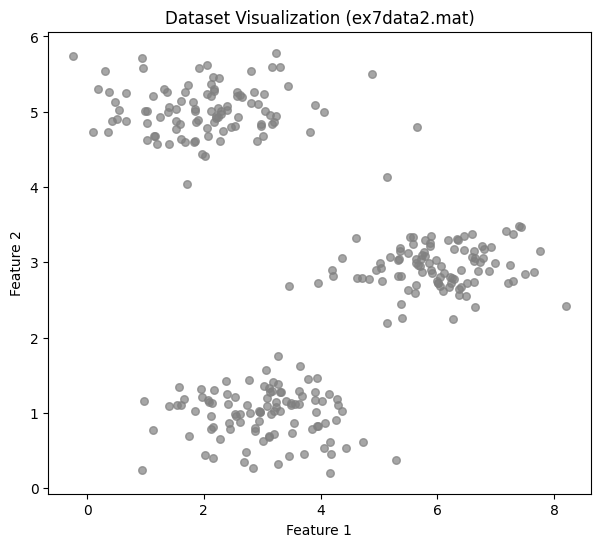

In [1]:
from google.colab import files
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# Ask user to upload ex7data2.mat
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

# Load the .mat file
data = sio.loadmat(filename)
X = data['X']

print("Shape of X:", X.shape)
print(X[:5])  # display first few data points

# Visualize the data
plt.figure(figsize=(7,6))
plt.scatter(X[:,0], X[:,1], s=30, c='gray', alpha=0.7)
plt.title("Dataset Visualization (ex7data2.mat)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [2]:
def find_closest_centroids(X, centroids):
    """Assign each data point to the closest centroid."""
    m = X.shape[0]
    K = centroids.shape[0]
    idx = np.zeros(m, dtype=int)

    for i in range(m):
        distances = np.linalg.norm(X[i] - centroids, axis=1)
        idx[i] = np.argmin(distances)
    return idx

# Test the function
initial_centroids = np.array([[3, 3], [6, 2], [8, 5]])
idx = find_closest_centroids(X, initial_centroids)

print("Closest centroids for first 3 examples:", idx[:3])


Closest centroids for first 3 examples: [0 2 1]


In [3]:
def compute_centroids(X, idx, K):
    """Compute new centroids as the mean of assigned data points."""
    n = X.shape[1]
    centroids = np.zeros((K, n))

    for k in range(K):
        points = X[idx == k]
        if len(points) > 0:
            centroids[k] = np.mean(points, axis=0)
    return centroids

# Test with previous assignment
K = 3
new_centroids = compute_centroids(X, idx, K)
print("New centroids:\n", new_centroids)


New centroids:
 [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


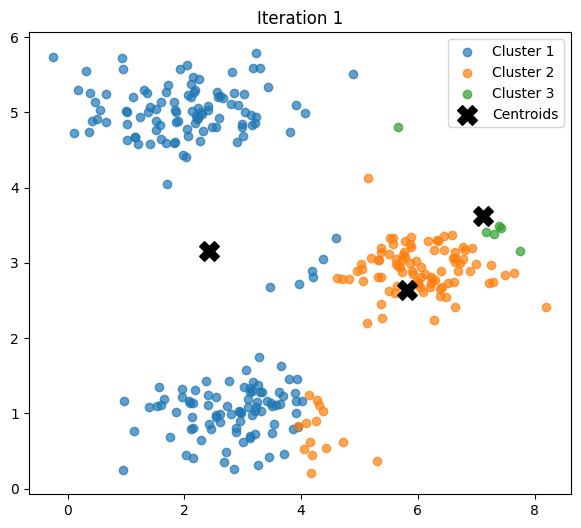

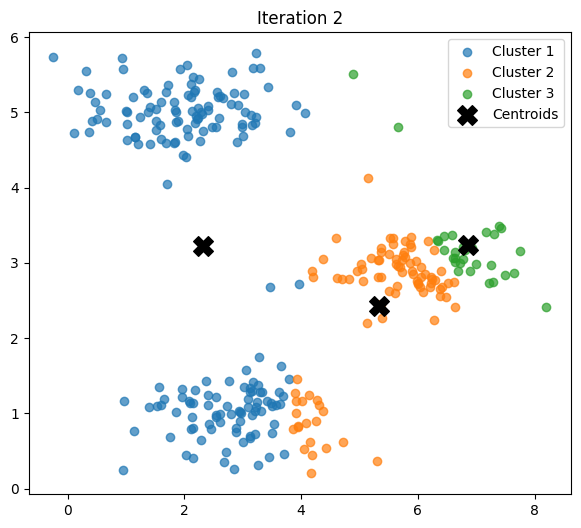

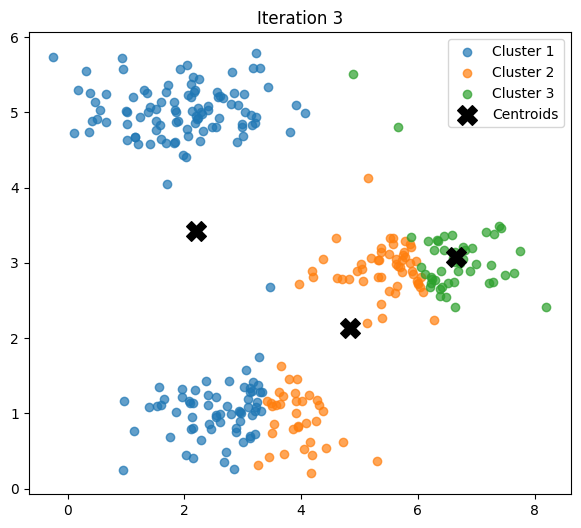

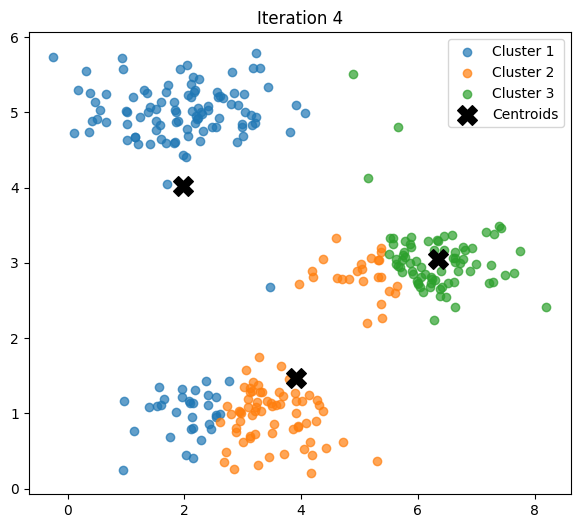

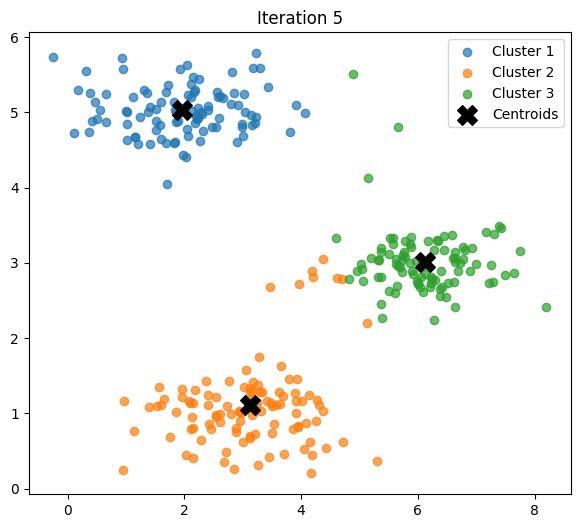

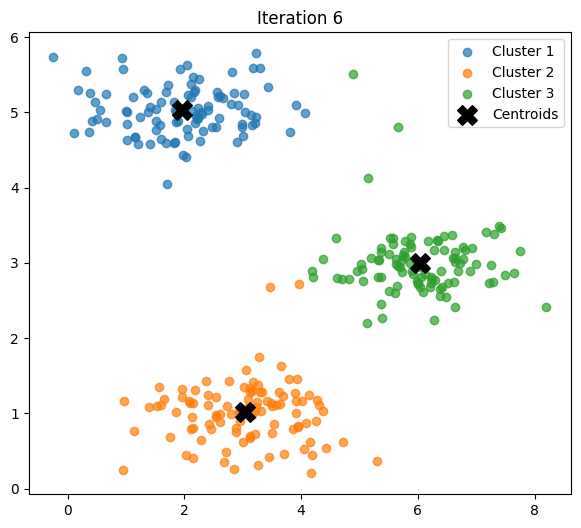

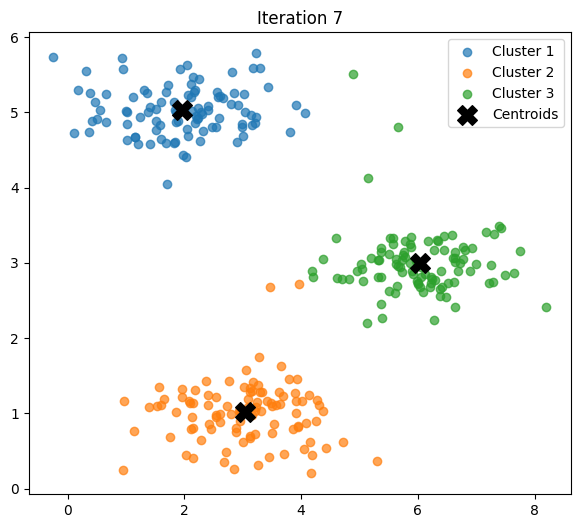

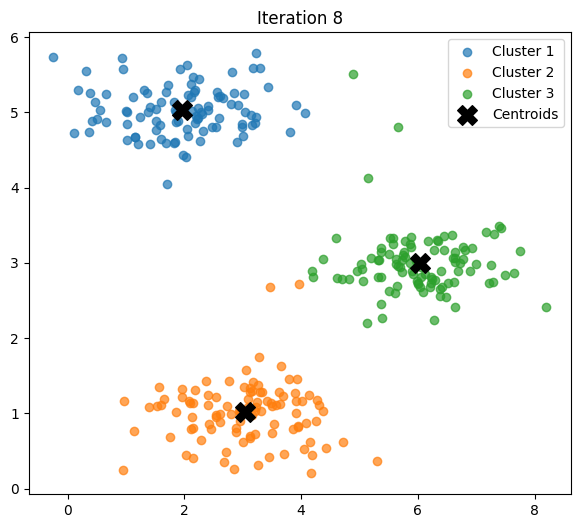

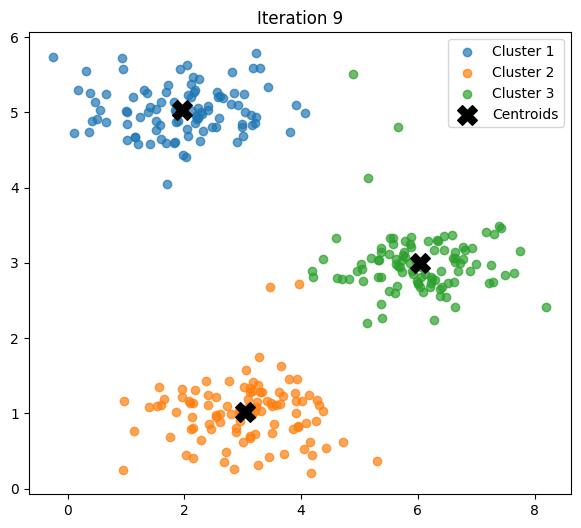

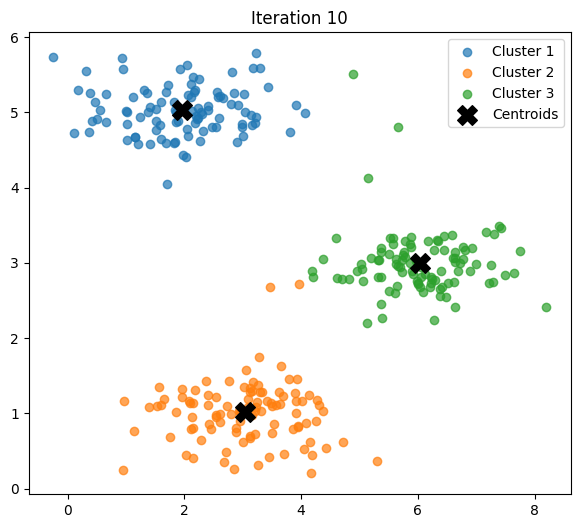

In [4]:
def run_k_means(X, initial_centroids, max_iters=10):
    """Run the K-Means algorithm."""
    centroids = initial_centroids
    K = centroids.shape[0]

    for i in range(max_iters):
        idx = find_closest_centroids(X, centroids)
        centroids = compute_centroids(X, idx, K)

        # Plot clusters each iteration
        plt.figure(figsize=(7,6))
        for k in range(K):
            cluster_points = X[idx == k]
            plt.scatter(cluster_points[:,0], cluster_points[:,1], label=f'Cluster {k+1}', alpha=0.7)
        plt.scatter(centroids[:,0], centroids[:,1], s=200, c='black', marker='X', label='Centroids')
        plt.title(f'Iteration {i+1}')
        plt.legend()
        plt.show()

    return centroids, idx

# Run K-means
final_centroids, final_idx = run_k_means(X, initial_centroids, max_iters=10)


In [5]:
def init_centroids(X, K):
    """Randomly select K data points as initial centroids."""
    random_indices = np.random.choice(X.shape[0], K, replace=False)
    return X[random_indices]

# Test random initialization
K = 3
random_centroids = init_centroids(X, K)
print("Randomly initialized centroids:\n", random_centroids)


Randomly initialized centroids:
 [[2.98340757 4.84046406]
 [1.40372638 4.57527684]
 [1.82975993 4.59657288]]


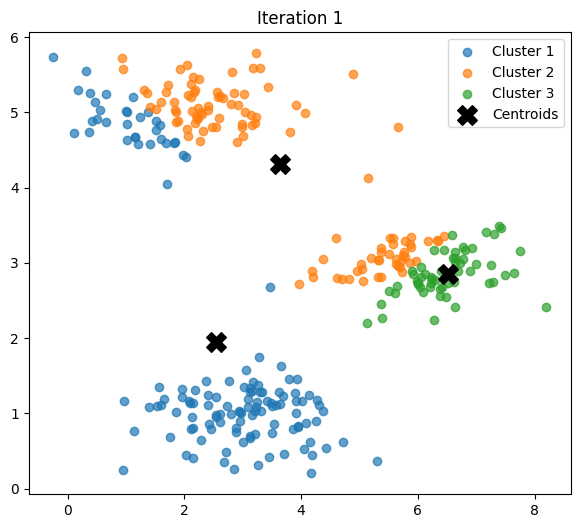

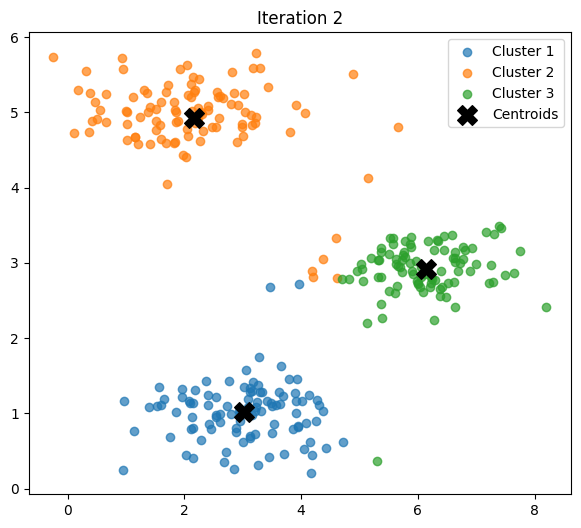

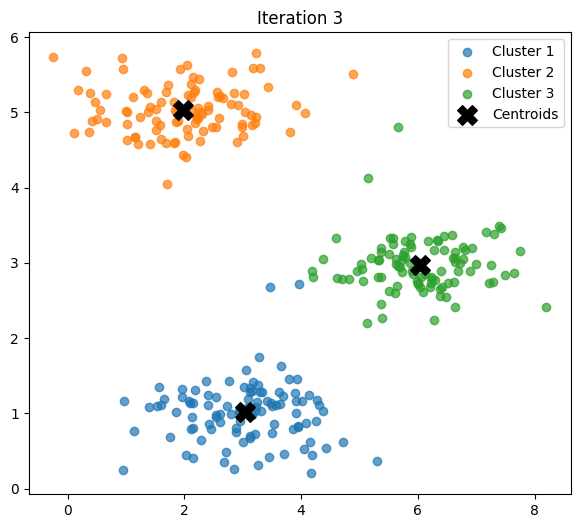

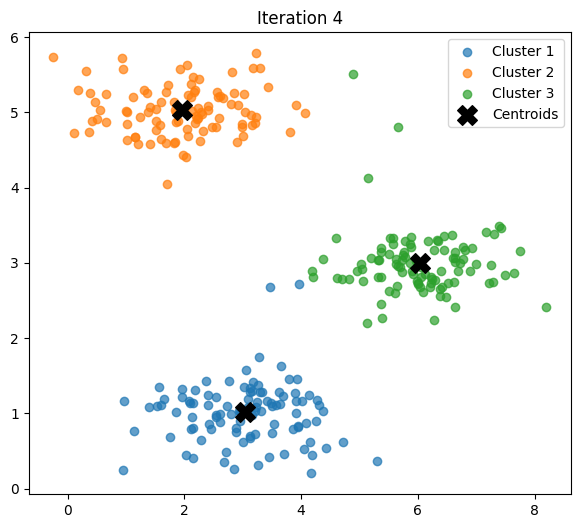

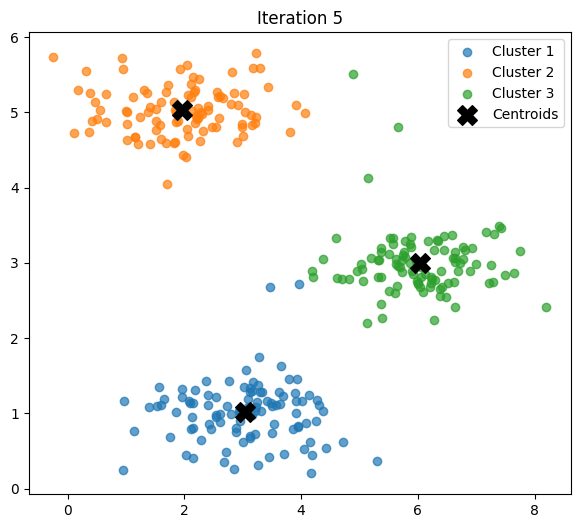

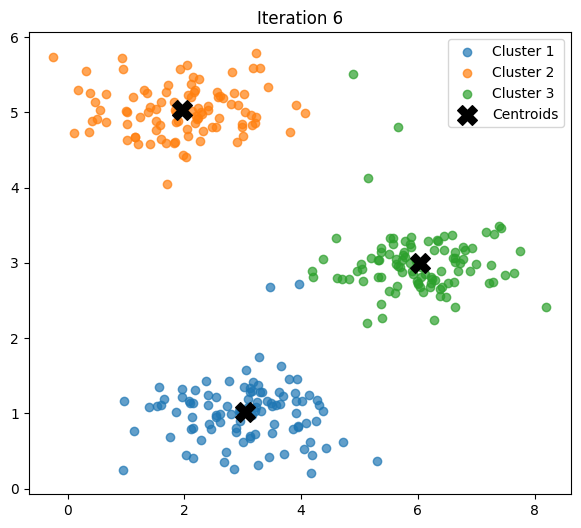

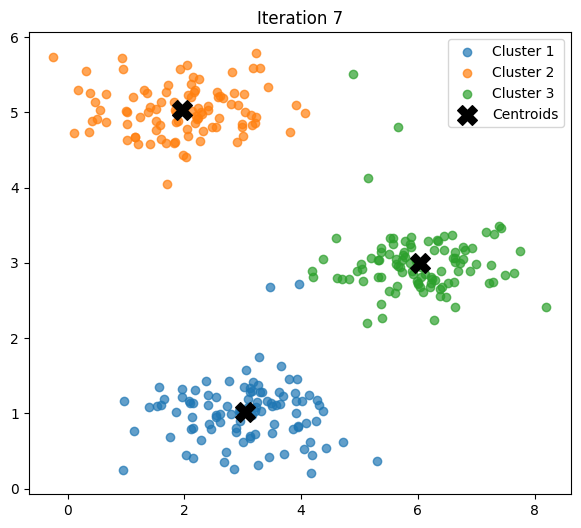

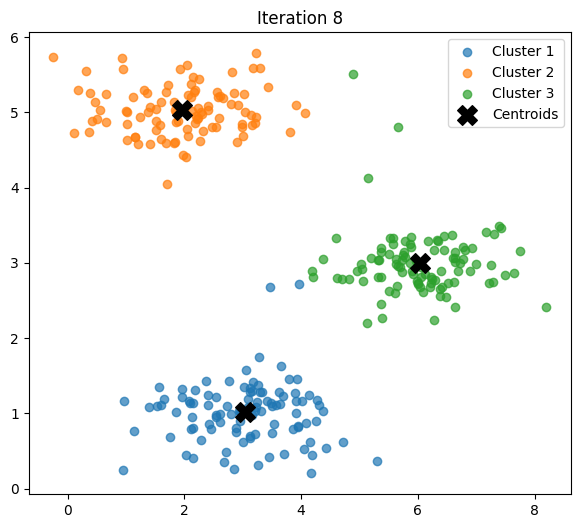

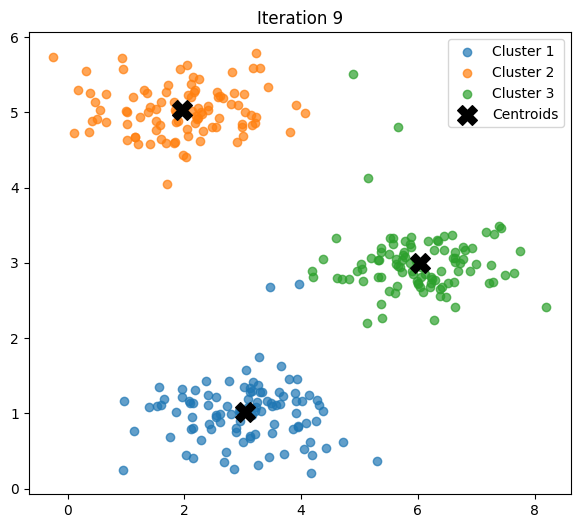

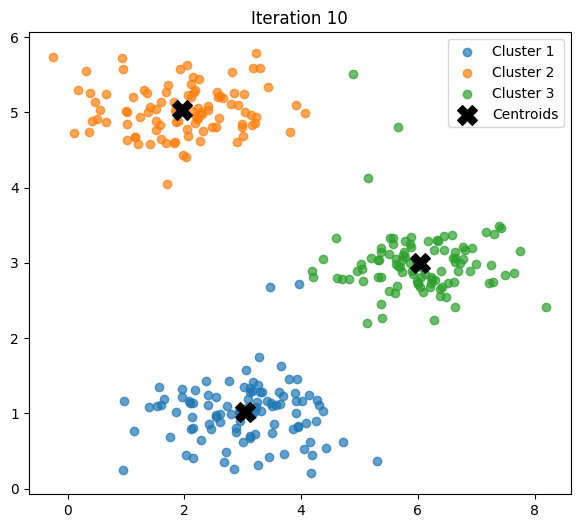

Final centroids:
 [[3.04367119 1.01541041]
 [1.95399466 5.02557006]
 [6.03366736 3.00052511]]


In [6]:
K = 3
initial_centroids = init_centroids(X, K)
final_centroids, final_idx = run_k_means(X, initial_centroids, max_iters=10)

print("Final centroids:\n", final_centroids)
